In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm
from matplotlib.ticker import ScalarFormatter

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [22]:
data = np.load("1d-differmethod-effect.npz")

t = data["times"]
ssfm = data["psi_ssfm"]  
#fssfm = data["psi_filtered_ssfm"] 
qssfm = data["psi_filtered_qssfm"]
qssfm_with_norm = data["psi_filtered_qssfm_with_norm"]

data0 = np.load("1d-differmethod-effect_n=3.npz")

t0 = data0["times"]
ssfm0 = data0["psi_ssfm"]  
#fssfm0 = data0["psi_filtered_ssfm"] 
qssfm0 = data0["psi_filtered_qssfm"]
qssfm_with_norm0 = data0["psi_filtered_qssfm_with_norm"]

In [ ]:
n = 8                                                  
N = 2**n                                                
x_max = 10
x = np.linspace(-x_max, x_max, N)

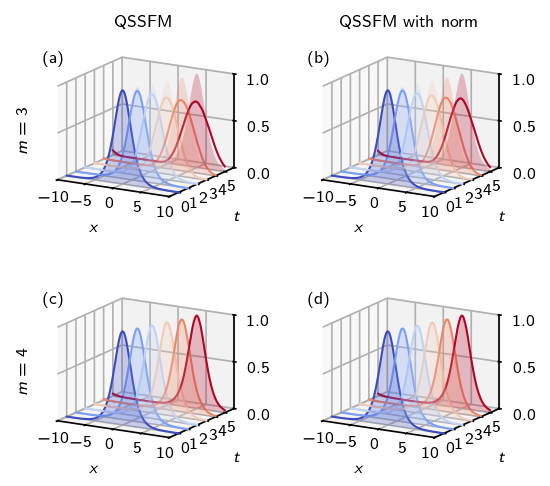

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fontsize = 8
dt = 0.01
t_values = [0, 1, 2, 3, 4, 5]

width = 8.6 / 2.54
height = width * 1

fig, axes = plt.subplots(
    2, 2, 
    figsize=(width, height),
    subplot_kw={'projection': '3d'}
)

cmap = plt.get_cmap('coolwarm')
colors = [cmap(i / (len(t_values) - 1)) for i in range(len(t_values))]


def plot_panel(
    ax,
    x,
    psi_line,
    psi_ref,
    title=None,
    show_legend=False,
    label_x=-0.18,
    label_y=1.05,
    label_fontsize=8,
    tick_pad_x=0,
    tick_pad_y=0,
    tick_pad_z=0,
    xlabel_pad=0,
    ylabel_pad=1,
):
    x = np.asarray(x)

    for j, t in enumerate(t_values):
        idx = int(round(t / dt))

        if idx >= len(psi_line):
            raise IndexError(f"psi_line: t={t} 对应 idx={idx} 超出长度 {len(psi_line)}")
        if idx >= len(psi_ref):
            raise IndexError(f"psi_ref: t={t} 对应 idx={idx} 超出长度 {len(psi_ref)}")

        line_curve = np.asarray(psi_line[idx])
        ref_curve = np.asarray(psi_ref[idx])

        if np.iscomplexobj(line_curve):
            line_curve = np.abs(line_curve)
        if np.iscomplexobj(ref_curve):
            ref_curve = np.abs(ref_curve)

        t_array = np.full(x.shape, t, dtype=float)
        ax.plot(
            x, t_array, line_curve,
            linewidth=1,
            color=colors[j],
            label=f"t={t}" if show_legend else None
        )

        X = np.tile(x, (2, 1))
        Y = np.full((2, x.size), t, dtype=float)
        Z = np.vstack([ref_curve, np.zeros_like(ref_curve)])

        ax.plot_surface(
            X, Y, Z,
            color=colors[j],
            alpha=0.25,
            linewidth=0,
            shade=False
        )

    ax.set_xlim(-10, 10)
    ax.set_ylim(-1, 6)
    ax.set_zlim(0, 1)
    ax.set_yticks(np.linspace(0, 5, 6))
    ax.set_zticks(np.linspace(0, 1, 3))

    ax.invert_xaxis()
    ax.invert_yaxis()

    ax.set_xlabel(r'$x$', labelpad=xlabel_pad, size=fontsize)
    ax.set_ylabel(r'$t$', labelpad=ylabel_pad, size=fontsize)

    ax.tick_params(axis='x', pad=tick_pad_x, labelsize=fontsize)
    ax.tick_params(axis='y', pad=tick_pad_y, labelsize=fontsize)
    ax.tick_params(axis='z', pad=tick_pad_z, labelsize=fontsize)

    ax.set_proj_type('ortho')
    ax.view_init(elev=15, azim=120)
    ax.grid(True)

    if title is not None:
        ax.text2D(
            label_x, label_y, title,
            transform=ax.transAxes,
            fontsize=label_fontsize,
            va='top', ha='left'
        )

    if show_legend:
        ax.legend(frameon=False, fontsize=fontsize)


def add_outer_labels(
    axes,
    row_labels=None,   
    col_labels=None,   
    row_x=-0.30,       
    col_y=1.08,        
    fontsize=8
):

    nrows, ncols = axes.shape

    if row_labels is not None:
        for i in range(nrows):
            axes[i, 0].text2D(
                row_x, 0.5, row_labels[i],
                transform=axes[i, 0].transAxes,
                rotation=90,
                va='center', ha='center',
                fontsize=fontsize
            )

    if col_labels is not None:
        for j in range(ncols):
            axes[0, j].text2D(
                0.5, col_y, col_labels[j],
                transform=axes[0, j].transAxes,
                va='bottom', ha='center',
                fontsize=fontsize
            )


plot_panel(
    axes[0, 0], x, qssfm0, ssfm0,
    title='(a)',
    label_x=0, label_y=0.9,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=-1,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)

plot_panel(
    axes[0, 1], x, qssfm_with_norm0, ssfm0,
    title='(b)',
    label_x=0, label_y=0.9,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=-1,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)
plot_panel(
    axes[1, 0], x, qssfm, ssfm,
    title='(c)',
    label_x=0, label_y=0.9,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=-1,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)

plot_panel(
    axes[1, 1], x, qssfm_with_norm, ssfm,
    title='(d)',
    label_x=0, label_y=0.9,
    tick_pad_x=-5, tick_pad_y=-5, tick_pad_z=-1,
    xlabel_pad=-5, ylabel_pad=-5,
    show_legend=False
)


add_outer_labels(
    axes,
    row_labels=['$m=3$', '$m=4$'],   
    col_labels=['QSSFM', 'QSSFM with norm'], 
    row_x=-0.1,
    col_y=1,
    fontsize=8
)

plt.subplots_adjust(left=0.04, right=0.98, bottom=0.08, top=0.95, wspace=0.25)

plt.savefig("1D_differmethod.svg", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.savefig("1D_differmethod.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)


In [ ]:
data0 = np.load("1d-differmethod-effect_n=3.npz")

t = data0["times"]
energy03 = data0["energy0"]  
energy23= data0["energy2"]  
energy33 = data0["energy3"]  
momentum03 = data0["momentum0"]  
momentum23 = data0["momentum2"]  
momentum33 = data0["momentum3"]  


data1 = np.load("1d-differmethod-effect.npz")

t1 = data1["times"]
energy0 = data1["energy0"]  
energy2 = data1["energy2"]  
energy3 = data1["energy3"]  
momentum0 = data1["momentum0"]  
momentum2 = data1["momentum2"]  
momentum3 = data1["momentum3"]  

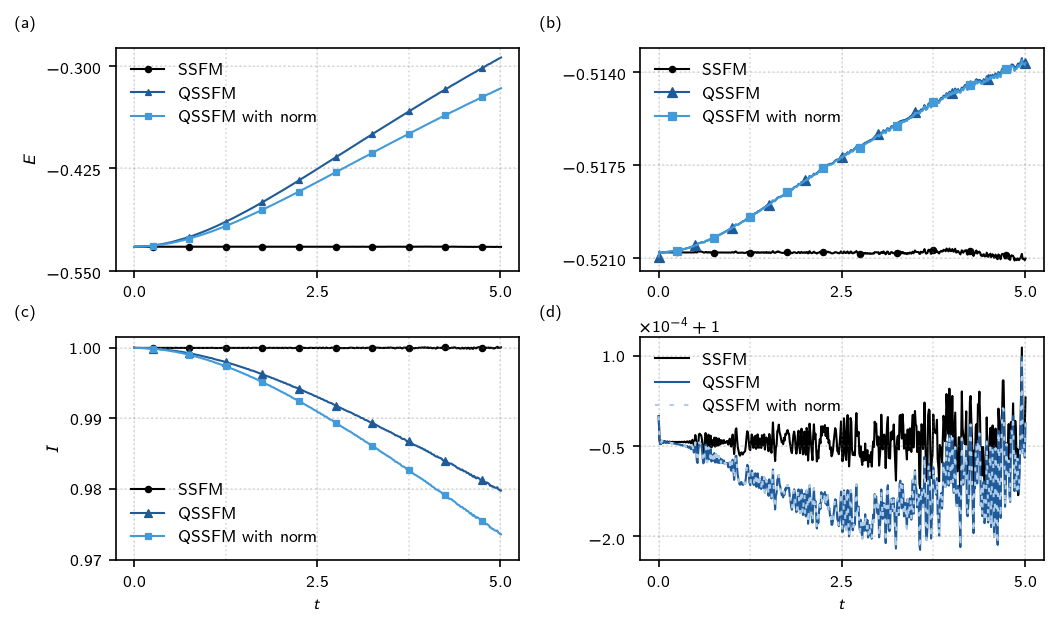

In [ ]:
width = 17.9 / 2.54
height = width * 0.6

light_blue = '#AFCDEA'
mid_blue   = "#429ad9"
dark_blue  = '#1F5A99'


def add_reference_lines(ax, h_values, v_values,
                        color='0.5', linestyle=':',
                        linewidth=0.8, alpha=0.3):
    for y in h_values:
        ax.axhline(y, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)
    for x in v_values:
        ax.axvline(x, linestyle=linestyle, linewidth=linewidth,
                   color=color, alpha=alpha)


def style_axis(ax, xlabel, ylabel=None,
               xticks=None, yticks=None,
               label_fontsize=fontsize,
               tick_fontsize=fontsize,
               y_sci=False,
               sci_powerlimits=(-2, 2)):

    ax.grid(True, which='both',
            linestyle='--',
            linewidth=0.5,
            color='0.8',
            alpha=0.3)

    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(axis='both', labelsize=tick_fontsize)

    if y_sci:
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits(sci_powerlimits)
        ax.yaxis.set_major_formatter(formatter)
        ax.ticklabel_format(axis='y', style='sci', scilimits=sci_powerlimits)
def add_panel_label(ax, label, x=-0.25, y=1.15, fontsize=8):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top', ha='left'
    )


def plot_lines(ax, x, line_specs):
    lines = []

    for spec in line_specs:
        line, = ax.plot(
            x,
            spec['y'],
            color=spec.get('color', 'k'),
            linewidth=spec.get('linewidth', 1.0),
            linestyle=spec.get('linestyle', '-'),
            label=spec.get('label', None),
            marker=spec.get('marker', None),
            markersize=spec.get('markersize', None),
            markevery=spec.get('markevery', None),
            markerfacecolor=spec.get('markerfacecolor', None),
            markeredgecolor=spec.get('markeredgecolor', None),
            markeredgewidth=spec.get('markeredgewidth', None),
            alpha=spec.get('alpha', 1.0),
            zorder=spec.get('zorder', None),
        )

        if spec.get('dashes', None) is not None:
            line.set_dashes(spec['dashes'])

        lines.append(line)

    return lines

def setup_panel(ax, x, line_specs, panel_label,
                xlabel=r"$t$", ylabel=None,
                xticks=None, yticks=None,
                hline_values=None, vline_values=None,
                legend=True,
                legend_order=None,  
                y_sci=False,
                sci_powerlimits=(-2, 2)):
    
    lines = plot_lines(ax, x, line_specs)

    style_axis(
        ax,
        xlabel=xlabel,
        ylabel=ylabel,
        xticks=xticks,
        yticks=yticks,
        y_sci=y_sci,
        sci_powerlimits=sci_powerlimits
    )

    if hline_values is not None or vline_values is not None:
        add_reference_lines(
            ax,
            h_values=[] if hline_values is None else hline_values,
            v_values=[] if vline_values is None else vline_values
        )

    if legend:
        if legend_order is None:
            ax.legend(frameon=False, fontsize=fontsize)
        else:
            legend_lines = [lines[i] for i in legend_order]
            legend_labels = [line.get_label() for line in legend_lines]
            ax.legend(legend_lines, legend_labels, frameon=False, fontsize=fontsize)

    add_panel_label(ax, panel_label)

panel_configs = [
    {
        "x": t,
        "line_specs": [
            {"y": energy03, "color": "black", "linewidth": 1, "label": r"SSFM",
                "marker": "o",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markeredgewidth": 0.6},
            {"y": energy23,
                "color": dark_blue,
                "linewidth": 1,
                "label": r"QSSFM",
                "marker": "^",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6},
            {"y": energy33, "color": mid_blue, "linewidth": 1, "label": r"QSSFM with norm",
                "color": mid_blue,
                "marker": "s",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6}
        ],
        "panel_label": "(a)",
        "xlabel": None,
        "ylabel": r"$E$",
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(-0.55, -0.3, 3),
        "hline_values": np.linspace(-0.55, -0.3, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "y_sci": True,
    },
    {
        "x": t1,
        "line_specs": [
            {"y": energy0, "color": "black", "linewidth": 1, "label": r"SSFM",
                "marker": "o",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markeredgewidth": 0.6},
            {"y": energy2,
                "color": dark_blue,
                "linewidth": 1,
                "label": r"QSSFM",
                "marker": "^",
                "markersize": 5,
                "markevery": 50,
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6},
            {"y": energy3, "color": mid_blue, "linewidth": 1, "label": r"QSSFM with norm",
                "marker": "s",
                "markersize": 4,
                "markevery": (25, 50),
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6}
        ],
        "panel_label": "(b)", 
        "xlabel": None,
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(-0.521, -0.514, 3),
        "hline_values": np.linspace(-0.521, -0.514, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "y_sci": True,
    },
    {
        "x": t,
        "line_specs": [
            {"y": momentum03, "color": "black", "linewidth": 1, "label": r"SSFM",
                "marker": "o",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markeredgewidth": 0.6},
            {"y": momentum23,
                "color": dark_blue,
                "linewidth": 1,
                "label": r"QSSFM",
                "marker": "^",
                "markersize": 4,
                "markevery":  (25, 50),
                "markerfacecolor": dark_blue,
                "markeredgecolor": dark_blue,
                "markeredgewidth": 0.6},
            {"y": momentum33, "color": mid_blue, "linewidth": 1, "label": r"QSSFM with norm",
                "marker": "s",
                "markersize": 3,
                "markevery": (25, 50),
                "markerfacecolor": mid_blue,
                "markeredgecolor": mid_blue,
                "markeredgewidth": 0.6},
        ],
        "panel_label": "(c)",
        "xlabel": r"$t$",
        "ylabel": r"$I$",
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0.97, 1, 4),
        "hline_values": np.linspace(0.97, 1, 4),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "sci_powerlimits": (-2, 2),
        "y_sci": True,
    },

    {
        "x": t1,
        "line_specs": [
            {"y": momentum0, "color": "black", "linewidth": 1, "label": r"SSFM"},
            {"y": momentum2,
                "color": dark_blue,
                "linewidth": 1,
                "label": r"QSSFM",
                #"marker": "^",
                #"markersize": 7,
                #"markevery": 20,
                #"markerfacecolor": dark_blue,
                #"markeredgecolor": dark_blue,
                #"markeredgewidth": 0.6,
                "alpha": 1},
            {"y": momentum3, "color": light_blue, "linewidth": 1, "linestyle": '--',"dashes":(2, 5),"label": r"QSSFM with norm", },
        ],
        "panel_label": "(d)",
        "xlabel": r"$t$",
        "ylabel": None,
        "xticks": np.linspace(0, 5, 3),
        "yticks": np.linspace(0.9998, 1.0001, 3),
        "hline_values": np.linspace(0.9998, 1.0001, 3),
        "vline_values": np.linspace(0, 5, 5),
        "legend": True,
        "legend_order": [0, 1, 2],   
        "sci_powerlimits": (-2, 2),
        "y_sci": True,
    },
]

def main():
    fig, axes = plt.subplots(2, 2, figsize=(width, height))

    for ax, cfg in zip(axes.flat, panel_configs):
        setup_panel(
            ax=ax,
            x=cfg["x"],
            line_specs=cfg["line_specs"],
            panel_label=cfg["panel_label"],
            xlabel=cfg["xlabel"],
            ylabel=cfg["ylabel"],
            xticks=cfg["xticks"],
            yticks=cfg["yticks"],
            hline_values=cfg["hline_values"],
            vline_values=cfg["vline_values"],
            legend=cfg["legend"],
            legend_order=cfg.get("legend_order", None), 
            y_sci=cfg.get("y_sci", False),
            sci_powerlimits=cfg.get("sci_powerlimits", (-2, 2)),
        )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    plt.savefig("differ_method_m=3_m=4.pdf", dpi=300,bbox_inches="tight", pad_inches=0.02)


if __name__ == "__main__":
    main()